Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9762 - dice_coefficient: 0.9475 - loss: 0.1452

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step

Epoch 1 Prediction Unique Labels: [0]


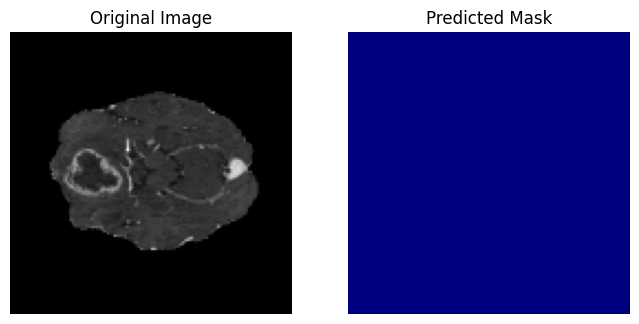

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 96s 90ms/step - accuracy: 0.9762 - dice_coefficient: 0.9476 - loss: 0.1451 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Epoch 2 Prediction Unique Labels: [0]


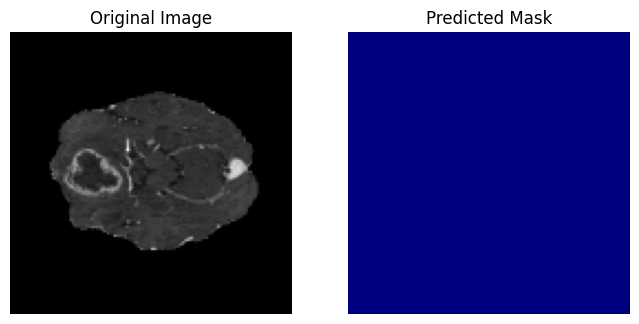

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.9776 - dice_coefficient: 0.9757 - loss: 0.1148 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Epoch 3 Prediction Unique Labels: [0]


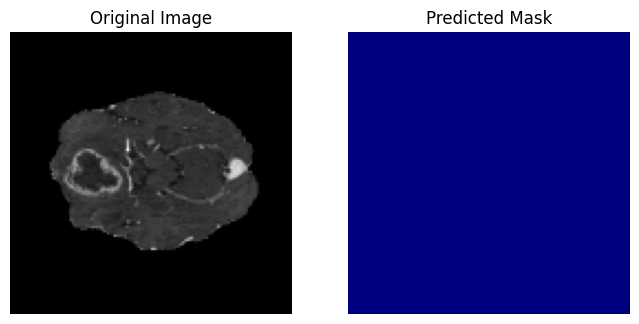

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 90s 90ms/step - accuracy: 0.9781 - dice_coefficient: 0.9763 - loss: 0.1117 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Epoch 4 Prediction Unique Labels: [0]


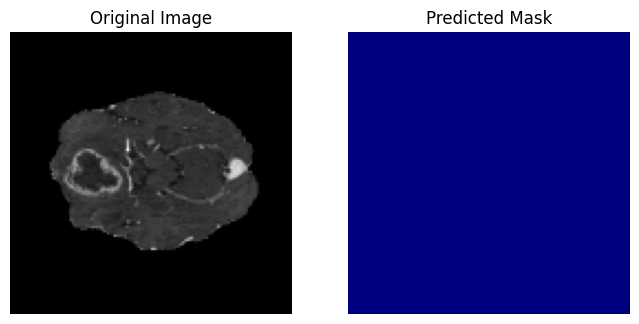

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 90s 90ms/step - accuracy: 0.9779 - dice_coefficient: 0.9760 - loss: 0.1132 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Epoch 5 Prediction Unique Labels: [0]


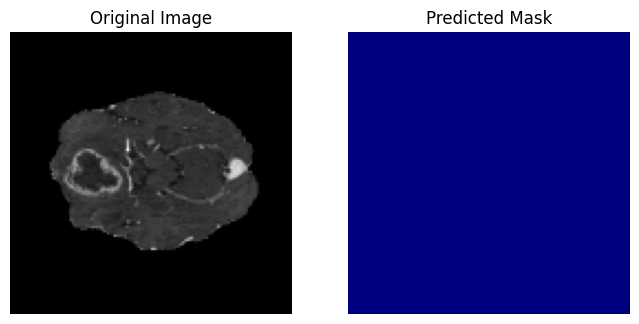

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.9781 - dice_coefficient: 0.9763 - loss: 0.1120 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Epoch 6 Prediction Unique Labels: [0]


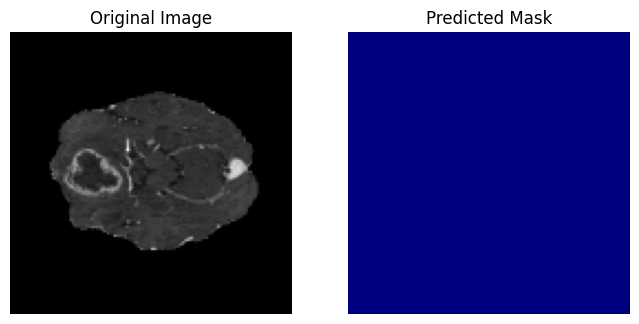

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 91s 91ms/step - accuracy: 0.9780 - dice_coefficient: 0.9761 - loss: 0.1125 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9762 - val_loss: 0.1121


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt

# ✅ Dice Coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# ✅ Dice Loss
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

# ✅ Focal Loss (with clipping for stability)
def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
    cross_entropy = -y_true * K.log(y_pred)
    weight = alpha * K.pow((1 - y_pred), gamma)
    return K.sum(weight * cross_entropy, axis=-1)

# ✅ Combined Loss: Dice + Focal
def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + K.mean(focal_loss(y_true, y_pred))

# ✅ Lightweight U-Net
def build_unet(input_shape=(128,128,1), num_classes=4):
    inputs = layers.Input(input_shape)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)

    u1 = layers.UpSampling2D((2,2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2,2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c5)
    return models.Model(inputs, outputs)

# ✅ Load Data
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"][:8000]  # Use subset for speed
Y_train = data["Y_train"][:8000]
X_val = data["X_val"][:1000]
Y_val = data["Y_val"][:1000]

# ✅ Callback for predictions after each epoch
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        sample = X_val[0:1]
        pred = self.model.predict(sample)
        mask = np.argmax(pred, axis=-1)[0]
        print(f"\nEpoch {epoch+1} Prediction Unique Labels: {np.unique(mask)}")

        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(sample[0,:,:,0], cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='jet')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# ✅ Compile & Train
model = build_unet()
model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy', dice_coefficient])

checkpoint = tf.keras.callbacks.ModelCheckpoint("unet_focal_dice.h5", save_best_only=True, monitor='val_loss')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, Y_train,
          validation_data=(X_val, Y_val),
          epochs=10,
          batch_size=8,
          callbacks=[checkpoint, early_stop, PredictionCallback()])


In [6]:
!pip install scipy

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/8b/c9/750d34788288d64ffbc94fdb4562f40f609d3f5ef27ab4f3a4ad00c9033e/scipy-1.16.0-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     -------------------------------- ----- 51.2/60.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------- ----- 51.2/60.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 268.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   ---------------------------------------- 0.2/38.6 MB 3.3 MB/s eta 0:00:12
    --------------------------------------- 0.5/38.6 MB 5.5 MB/s eta 0:00:07
    --------------------------------------- 0.7/38.6 MB 5.1 MB/s eta 0:00:08
   - -------------------------------


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt

# ✅ Generalized Dice Loss (handles imbalance)
def generalized_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    weights = 1.0 / (K.sum(y_true, axis=[0,1,2])**2 + smooth)
    numerator = 2 * K.sum(weights * K.sum(y_true * y_pred, axis=[0,1,2]))
    denominator = K.sum(weights * K.sum(y_true + y_pred, axis=[0,1,2]))
    return 1 - (numerator + smooth) / (denominator + smooth)

# ✅ Weighted Categorical Crossentropy
def weighted_ce(class_weights):
    def loss(y_true, y_pred):
        y_true = K.cast(y_true, 'float32')
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        loss = -K.sum(y_true * K.log(y_pred) * class_weights, axis=-1)
        return loss
    return loss

# ✅ Lightweight U-Net
def build_unet(input_shape=(128,128,1), num_classes=4):
    inputs = layers.Input(input_shape)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)

    u1 = layers.UpSampling2D((2,2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2,2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c5)
    return models.Model(inputs, outputs)

# ✅ Load Data
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"][:8000]
Y_train = data["Y_train"][:8000]
X_val = data["X_val"][:1000]
Y_val = data["Y_val"][:1000]

# ✅ Compute Class Weights
flat = np.argmax(Y_train, axis=-1).flatten()
unique, counts = np.unique(flat, return_counts=True)
total = np.sum(counts)
class_weights = {i: total/(len(unique)*c) for i,c in zip(unique, counts)}
print("Class Weights:", class_weights)
class_weights_list = np.array([class_weights[i] for i in range(len(unique))])

# ✅ Callback for Predictions
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        sample = X_val[0:1]
        pred = self.model.predict(sample)
        mask = np.argmax(pred, axis=-1)[0]
        print(f"\nEpoch {epoch+1} Prediction Unique Labels: {np.unique(mask)}")

        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(sample[0,:,:,0], cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='jet')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# ✅ Build and Compile Model
model = build_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=lambda y_true, y_pred: generalized_dice_loss(y_true, y_pred) + 
                                          weighted_ce(class_weights_list)(y_true, y_pred),
              metrics=['accuracy'])

# ✅ Train
checkpoint = tf.keras.callbacks.ModelCheckpoint("unet_balanced.h5", save_best_only=True, monitor='val_loss')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, Y_train,
          validation_data=(X_val, Y_val),
          epochs=20,
          batch_size=8,
          callbacks=[checkpoint, early_stop, PredictionCallback()])
